已加载 Imbalanced Model 和 Balanced Model 的结果
对比图已保存为 model_comparison.png


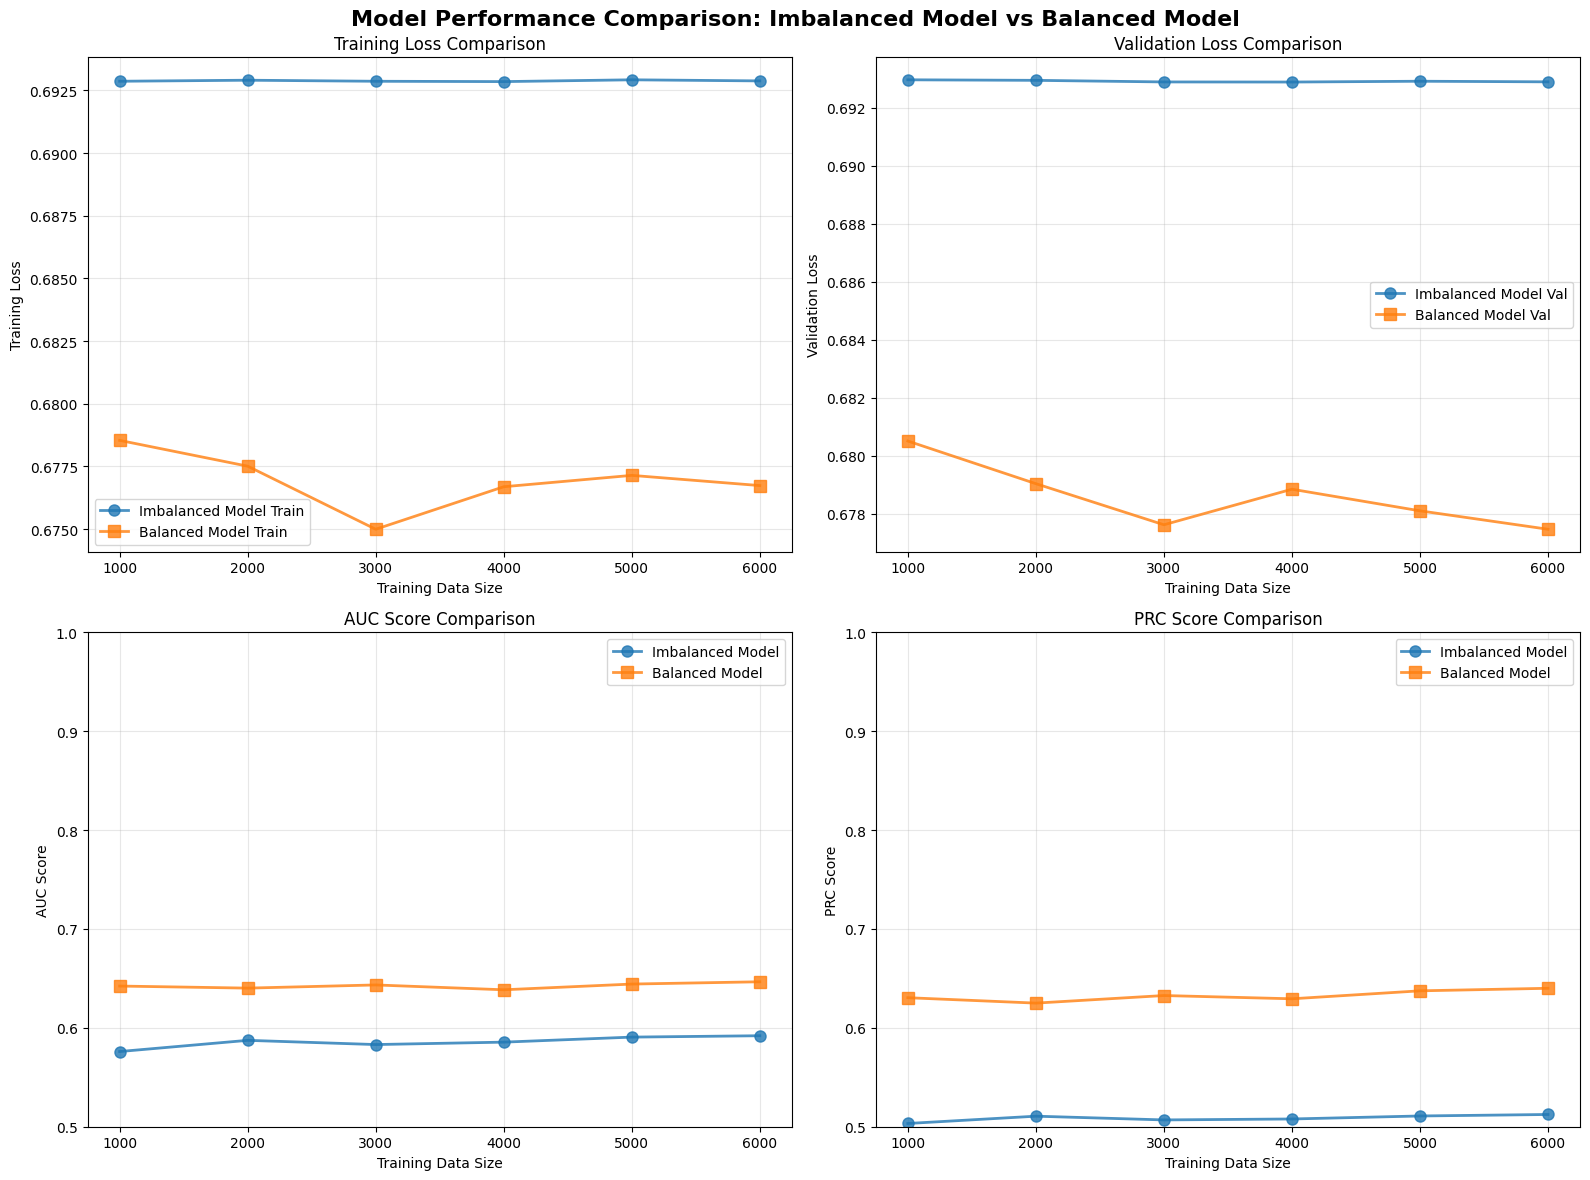

提升的auc,prc [11.49715854  8.99204645 10.33952594  9.04203326  9.08305028  9.21817976] [25.2753701  22.39476329 24.81767941 23.93517136 24.77352743 24.91013507]
差异对比图已保存为 model_comparison_difference.png


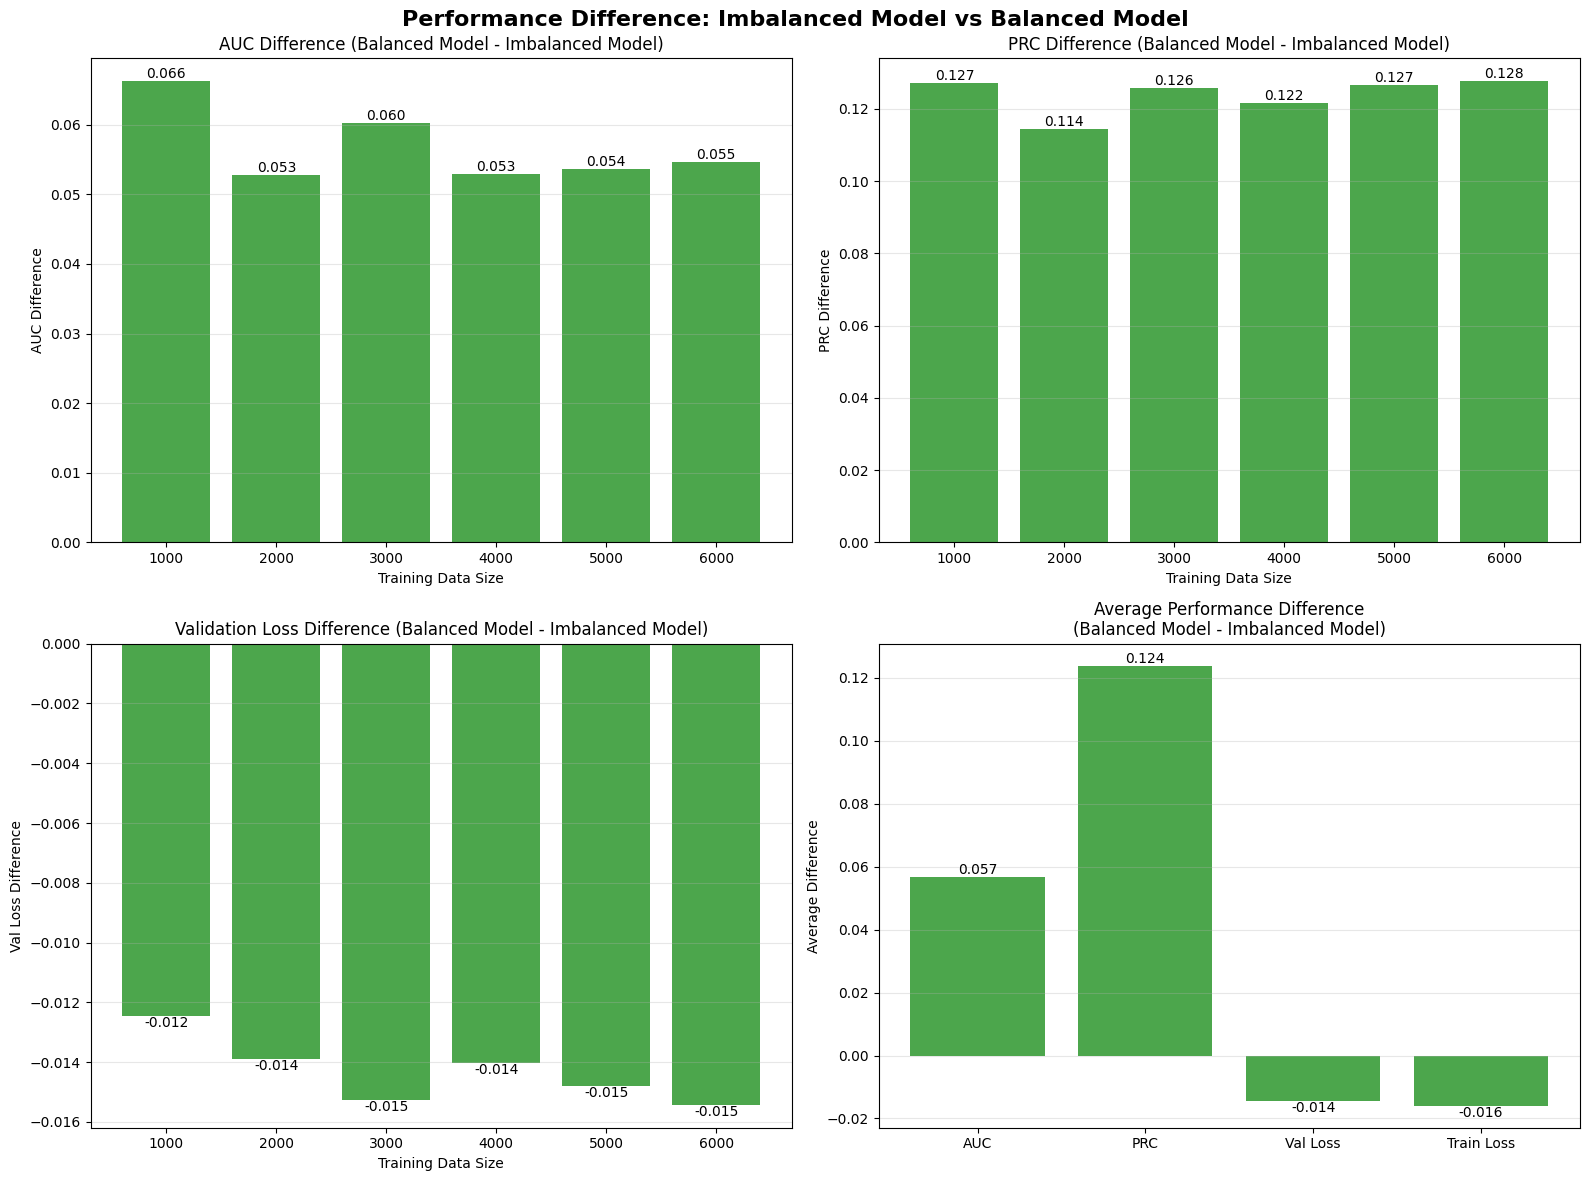


模型性能对比分析
最终 AUC:
  Imbalanced Model: 0.5920
  Balanced Model: 0.6466
  差异: 0.0546 (Balanced Model 优于 Imbalanced Model)
  提升百分点: +5.46 %
  提升百分点: +0.43 %

最终 PRC:
  Imbalanced Model: 0.5124
  Balanced Model: 0.6400
  差异: 0.1276 (Balanced Model 优于 Imbalanced Model)
  提升百分点: +12.76 %
  提升百分点: +0.43 %

最终验证损失:
  Imbalanced Model: 0.6929
  Balanced Model: 0.6775
  差异: -0.0154 (Balanced Model 优于 Imbalanced Model)
  变化百分点(损失): -1.54 % (降低)

总体评价: Balanced Model 总体表现更好


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

def plot_comparison_results(results1, results2, label1="Model 1", label2="Model 2", save_path=None):
    """
    对比两个results数组的可视化函数
    
    Parameters:
    -----------
    results1, results2 : dict
        两个results字典，格式为：
        {
            "sizes": [size1, size2, ...],
            "final_train_loss": [loss1, loss2, ...],
            "final_val_loss": [loss1, loss2, ...],
            "final_prc": [prc1, prc2, ...],
            "final_auc": [auc1, auc2, ...]
        }
    label1, label2 : str
        两个模型的标签名称
    save_path : str, optional
        图片保存路径
    """
    
    # 验证两个results的sizes是否一致
    if results1["sizes"] != results2["sizes"]:
        print("警告: 两个results的数据量大小不一致，将使用results1的sizes")
    
    sizes = results1["sizes"]
    
    # 创建2x2的子图布局
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Model Performance Comparison: {label1} vs {label2}', fontsize=16, fontweight='bold')
    
    # 颜色设置
    color1, color2 = '#1f77b4', '#ff7f0e'  # 蓝色和橙色
    
    # 1. 训练损失对比
    ax1.plot(sizes, results1["final_train_loss"], 'o-', linewidth=2, markersize=8, 
             label=f'{label1} Train', color=color1, alpha=0.8)
    ax1.plot(sizes, results2["final_train_loss"], 's-', linewidth=2, markersize=8, 
             label=f'{label2} Train', color=color2, alpha=0.8)
    ax1.set_xlabel('Training Data Size')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('Training Loss Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 验证损失对比
    ax2.plot(sizes, results1["final_val_loss"], 'o-', linewidth=2, markersize=8, 
             label=f'{label1} Val', color=color1, alpha=0.8)
    ax2.plot(sizes, results2["final_val_loss"], 's-', linewidth=2, markersize=8, 
             label=f'{label2} Val', color=color2, alpha=0.8)
    ax2.set_xlabel('Training Data Size')
    ax2.set_ylabel('Validation Loss')
    ax2.set_title('Validation Loss Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. AUC分数对比
    ax3.plot(sizes, results1["final_auc"], 'o-', linewidth=2, markersize=8, 
             label=label1, color=color1, alpha=0.8)
    ax3.plot(sizes, results2["final_auc"], 's-', linewidth=2, markersize=8, 
             label=label2, color=color2, alpha=0.8)
    ax3.set_xlabel('Training Data Size')
    ax3.set_ylabel('AUC Score')
    ax3.set_title('AUC Score Comparison')
    ax3.set_ylim(0.5, 1.0)  # AUC通常在这个范围
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. PRC分数对比
    ax4.plot(sizes, results1["final_prc"], 'o-', linewidth=2, markersize=8, 
             label=label1, color=color1, alpha=0.8)
    ax4.plot(sizes, results2["final_prc"], 's-', linewidth=2, markersize=8, 
             label=label2, color=color2, alpha=0.8)
    ax4.set_xlabel('Training Data Size')
    ax4.set_ylabel('PRC Score')
    ax4.set_title('PRC Score Comparison')
    ax4.set_ylim(0.5, 1.0)  # PRC通常在这个范围
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"对比图已保存为 {save_path}")
    
    plt.show()

def plot_difference_comparison(results1, results2, label1="Model 1", label2="Model 2", save_path=None):
    """
    绘制两个模型性能差异的详细对比图
    """
    sizes = results1["sizes"]
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Performance Difference: {label1} vs {label2}', fontsize=16, fontweight='bold')
    
    # 计算差异 (results2 - results1)
    auc_diff = np.array(results2["final_auc"]) - np.array(results1["final_auc"])
    imporved_auc = auc_diff/results1["final_auc"]
    prc_diff = np.array(results2["final_prc"]) - np.array(results1["final_prc"])
    imporved_prc = prc_diff/results1["final_prc"]
    val_loss_diff = np.array(results2["final_val_loss"]) - np.array(results1["final_val_loss"])
    train_loss_diff = np.array(results2["final_train_loss"]) - np.array(results1["final_train_loss"])
    print("提升的auc,prc",imporved_auc*100,imporved_prc*100)
    # 1. AUC差异
    bars1 = ax1.bar(range(len(sizes)), auc_diff, color=['red' if x < 0 else 'green' for x in auc_diff], alpha=0.7)
    ax1.set_xlabel('Training Data Size')
    ax1.set_ylabel('AUC Difference')
    ax1.set_title(f'AUC Difference ({label2} - {label1})')
    ax1.set_xticks(range(len(sizes)))
    ax1.set_xticklabels(sizes)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 在柱状图上添加数值标签
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    # 2. PRC差异
    bars2 = ax2.bar(range(len(sizes)), prc_diff, color=['red' if x < 0 else 'green' for x in prc_diff], alpha=0.7)
    ax2.set_xlabel('Training Data Size')
    ax2.set_ylabel('PRC Difference')
    ax2.set_title(f'PRC Difference ({label2} - {label1})')
    ax2.set_xticks(range(len(sizes)))
    ax2.set_xticklabels(sizes)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    # 3. 验证损失差异
    bars3 = ax3.bar(range(len(sizes)), val_loss_diff, color=['green' if x < 0 else 'red' for x in val_loss_diff], alpha=0.7)
    ax3.set_xlabel('Training Data Size')
    ax3.set_ylabel('Val Loss Difference')
    ax3.set_title(f'Validation Loss Difference ({label2} - {label1})')
    ax3.set_xticks(range(len(sizes)))
    ax3.set_xticklabels(sizes)
    ax3.grid(True, alpha=0.3, axis='y')
    
    for i, bar in enumerate(bars3):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    # 4. 汇总统计
    metrics = ['AUC', 'PRC', 'Val Loss', 'Train Loss']
    avg_differences = [np.mean(auc_diff), np.mean(prc_diff), np.mean(val_loss_diff), np.mean(train_loss_diff)]
    colors = ['green' if (x > 0 and metric != 'Val Loss' and metric != 'Train Loss') or 
                      (x < 0 and (metric == 'Val Loss' or metric == 'Train Loss')) 
              else 'red' for x, metric in zip(avg_differences, metrics)]
    
    bars4 = ax4.bar(metrics, avg_differences, color=colors, alpha=0.7)
    ax4.set_ylabel('Average Difference')
    ax4.set_title(f'Average Performance Difference\n({label2} - {label1})')
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path.replace('.png', '_difference.png'), dpi=300, bbox_inches='tight')
        print(f"差异对比图已保存为 {save_path.replace('.png', '_difference.png')}")
    
    plt.show()

def load_results_and_compare(file1, file2, label1="Model 1", label2="Model 2"):
    """
    从pkl文件加载两个results并绘制对比图
    
    Parameters:
    -----------
    file1, file2 : str
        两个pkl文件路径
    label1, label2 : str
        两个模型的标签
    """
    
    # 加载第一个results
    with open(file1, 'rb') as f:
        results1 = pickle.load(f)
    
    # 加载第二个results
    with open(file2, 'rb') as f:
        results2 = pickle.load(f)
    
    print(f"已加载 {label1} 和 {label2} 的结果")
    
    # 绘制性能对比图
    plot_comparison_results(results1, results2, label1, label2, "model_comparison.png")
    
    # 绘制差异对比图
    plot_difference_comparison(results1, results2, label1, label2, "model_comparison.png")
    
    # 打印简要分析
    # print_comparison_analysis(results1, results2, label1, label2)
    print_comparison_improve(results1, results2, label1, label2)
    
    return results1, results2

def print_comparison_analysis(results1, results2, label1, label2):
    """
    打印两个模型的简要对比分析
    """
    print("\n" + "="*50)
    print("模型性能对比分析")
    print("="*50)
    
    # AUC对比
    auc1_final = results1["final_auc"][-1]
    auc2_final = results2["final_auc"][-1]
    auc_diff = auc2_final - auc1_final
    
    print(f"最终AUC:")
    print(f"  {label1}: {auc1_final:.4f}")
    print(f"  {label2}: {auc2_final:.4f}")
    print(f"  差异: {auc_diff:.4f} ({label2} {'优于' if auc_diff > 0 else '劣于'} {label1})")
    
    # PRC对比
    prc1_final = results1["final_prc"][-1]
    prc2_final = results2["final_prc"][-1]
    prc_diff = prc2_final - prc1_final
    
    print(f"\n最终PRC:")
    print(f"  {label1}: {prc1_final:.4f}")
    print(f"  {label2}: {prc2_final:.4f}")
    print(f"  差异: {prc_diff:.4f} ({label2} {'优于' if prc_diff > 0 else '劣于'} {label1})")
    
    # 验证损失对比
    val_loss1_final = results1["final_val_loss"][-1]
    val_loss2_final = results2["final_val_loss"][-1]
    val_loss_diff = val_loss2_final - val_loss1_final
    
    print(f"\n最终验证损失:")
    print(f"  {label1}: {val_loss1_final:.4f}")
    print(f"  {label2}: {val_loss2_final:.4f}")
    print(f"  差异: {val_loss_diff:.4f} ({label2} {'优于' if val_loss_diff < 0 else '劣于'} {label1})")
    
    # 总体评价
    better_count = sum([
        1 if auc_diff > 0 else 0,
        1 if prc_diff > 0 else 0,
        1 if val_loss_diff < 0 else 0
    ])
    
    if better_count >= 2:
        overall = f"{label2} 总体表现更好"
    elif better_count <= 1:
        overall = f"{label1} 总体表现更好"
    else:
        overall = "两个模型表现相当"
    
    print(f"\n总体评价: {overall}")

def print_comparison_improve(results1, results2, label1, label2):
    """
    打印两个模型的简要对比分析，
    额外输出：提升百分点（percentage points）
    """
    print("\n" + "="*50)
    print("模型性能对比分析")
    print("="*50)
    
    # ---------- AUC 对比 ----------
    auc1_final = results1["final_auc"][-1]
    auc2_final = results2["final_auc"][-1]
    auc_diff = auc2_final - auc1_final
    auc_pp = auc_diff * 100  # 提升百分点
    auc_diff_balancec = results2["final_auc"][-1] - results2["final_auc"][0]
    auc_pp_balance = auc_diff_balancec * 100  # 提升百分点
    
    print(f"最终 AUC:")
    print(f"  {label1}: {auc1_final:.4f}")
    print(f"  {label2}: {auc2_final:.4f}")
    print(f"  差异: {auc_diff:.4f} ({label2} {'优于' if auc_diff > 0 else '劣于'} {label1})")
    print(f"  提升百分点: {auc_pp:+.2f} %")
    print(f"  提升百分点: {auc_pp_balance:+.2f} %")
    
    # ---------- PRC 对比 ----------
    prc1_final = results1["final_prc"][-1]
    prc2_final = results2["final_prc"][-1]
    prc_diff = prc2_final - prc1_final
    prc_pp = prc_diff * 100
    prc_diff_balancec = results2["final_auc"][-1] - results2["final_auc"][0]
    prc_pp_balance = prc_diff_balancec * 100  # 提升百分点
    
    
    print(f"\n最终 PRC:")
    print(f"  {label1}: {prc1_final:.4f}")
    print(f"  {label2}: {prc2_final:.4f}")
    print(f"  差异: {prc_diff:.4f} ({label2} {'优于' if prc_diff > 0 else '劣于'} {label1})")
    print(f"  提升百分点: {prc_pp:+.2f} %")
    print(f"  提升百分点: {prc_pp_balance:+.2f} %")
    
    # ---------- 验证损失对比 ----------
    val_loss1_final = results1["final_val_loss"][-1]
    val_loss2_final = results2["final_val_loss"][-1]
    val_loss_diff = val_loss2_final - val_loss1_final
    val_loss_pp = val_loss_diff * 100
    
    print(f"\n最终验证损失:")
    print(f"  {label1}: {val_loss1_final:.4f}")
    print(f"  {label2}: {val_loss2_final:.4f}")
    print(f"  差异: {val_loss_diff:.4f} ({label2} {'优于' if val_loss_diff < 0 else '劣于'} {label1})")
    print(f"  变化百分点(损失): {val_loss_pp:+.2f} % "
          f"({'降低' if val_loss_diff < 0 else '升高'})")

    
    # ---------- 总体评价 ----------
    better_count = sum([
        1 if auc_diff > 0 else 0,
        1 if prc_diff > 0 else 0,
        1 if val_loss_diff < 0 else 0
    ])
    
    if better_count >= 2:
        overall = f"{label2} 总体表现更好"
    elif better_count <= 1:
        overall = f"{label1} 总体表现更好"
    else:
        overall = "两个模型表现相当"
    
    print(f"\n总体评价: {overall}")

# 使用示例
if __name__ == "__main__":
    # 假设你已经有两个pkl文件
    # 直接调用这个函数即可
    results1, results2 = load_results_and_compare(
        "label_imbalanced.pkl", 
        "label_balanced.pkl",
        label1="Imbalanced Model",
        label2="Balanced Model"
    )



In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# ==========================
# 1. 图加载
# ==========================

def load_graph(node_csv, edge_csv, device="cpu"):
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)

    edges = pd.read_csv(edge_csv)
    src = torch.tensor(edges["src"].values, dtype=torch.int64)
    dst = torch.tensor(edges["dst"].values, dtype=torch.int64)

    g = dgl.graph((src, dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, dst, src)
    g = dgl.add_self_loop(g)


    return g.to(device), edges, num_nodes


# ==========================
# 2. 构造训练样本
# ==========================

def sample_non_edges(num_nodes, edges, num_samples):
    exist = set(zip(edges["src"], edges["dst"]))
    samples = []

    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        if s != d and (s, d) not in exist:
            samples.append((s, d))
    return samples


def build_samples(g, edges, num_nodes):
    pos = edges[edges["label"] == 1]
    neg = edges[edges["label"] == 2]

    src, dst, label = [], [], []

    for _, r in pos.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(1)

    for _, r in neg.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(2)

    # 采样无边
    non_edges = sample_non_edges(num_nodes, edges, len(pos))
    for s, d in non_edges:
        src.append(s)
        dst.append(d)
        label.append(0)

    return torch.tensor(src), torch.tensor(dst), torch.tensor(label)


# ==========================
# Dataset
# ==========================

class EdgeDataset(Dataset):
    def __init__(self, src, dst, label):
        self.src = src
        self.dst = dst
        self.label = label

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        return self.src[idx], self.dst[idx], self.label[idx]


# ==========================
# RGCN + 三分类 Decoder
# ==========================

from dgl.nn import GraphConv

class RGCNEncoder(nn.Module):
    def __init__(self, in_feats=16, h_feats=32, out_feats=32):
        super().__init__()
        self.layer1 = GraphConv(in_feats, h_feats)
        self.layer2 = GraphConv(h_feats, out_feats)

    def forward(self, g, feat):
        h = torch.relu(self.layer1(g, feat))
        h = self.layer2(g, h)
        return h


class EdgeClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, emb, src, dst):
        h = torch.cat([emb[src], emb[dst]], dim=1)
        return self.mlp(h)


class RGCNModel(nn.Module):
    def __init__(self, in_dim=16):
        super().__init__()
        self.encoder = RGCNEncoder(in_dim, 32, 32)
        self.decoder = EdgeClassifier(32, 64, 3)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)


# ==========================
# Train & Eval
# ==========================
def multi_class_pr_auc(labels, probs, num_classes=3):
    prcs = []
    for c in range(num_classes):
        y_true = (labels == c).astype(int)
        y_score = probs[:, c]

        if y_true.sum() == 0:   # 跳过没有真实样本的类别
            continue

        prc = average_precision_score(y_true, y_score)
        prcs.append(prc)

    return np.mean(prcs) if len(prcs) > 0 else 0.0

def evaluate(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro")

    # AUC（多分类用 OvR）
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)

    return total_loss, acc, pre, rec, f1, auc, prc


# ==========================
# 主函数
# ==========================

def train_model(node_csv, edge_csv):
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    g, edges, num_nodes = load_graph(node_csv, edge_csv, device)

    # 节点特征
    feat = torch.randn((num_nodes, 16), device=device)

    # 构造三分类样本
    src, dst, label = build_samples(g, edges, num_nodes)

    # Train / Val 划分
    s_train, s_val, d_train, d_val, y_train, y_val = train_test_split(
        src, dst, label, test_size=0.2, shuffle=True
    )

    train_loader = DataLoader(EdgeDataset(s_train, d_train, y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(EdgeDataset(s_val, d_val, y_val), batch_size=256, shuffle=False)

    model = RGCNModel(in_dim=16).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # ==========================
    # Training Loop
    # ==========================

    from tqdm import tqdm
    prc_list = []
    auc_list = []
    f1_list = []
    train_loss_list = []
    val_loss_list = []
    for epoch in range(20):
        model.train()
        total_loss = 0

        # tqdm 外层：epoch 进度
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=100)

        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # 在进度条实时显示当前 batch loss
            epoch_iter.set_postfix(loss=f"{loss.item():.4f}")

        # -------------------
        # 验证
        # -------------------
        val_loss, acc, pre, rec, f1, auc, prc = evaluate(model, val_loader, g, feat, device)
        prc_list.append(prc)
        auc_list.append(auc)
        f1_list.append(f1)
        train_loss_list.append(total_loss)
        val_loss_list.append(val_loss)

        print(
            f"[Epoch {epoch:02d}] "
            f"Train Loss={total_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Acc={acc:.4f} | Pre={pre:.4f} | Rec={rec:.4f} | "
            f"F1={f1:.4f} | AUC={auc:.4f} | PRC={prc:.4f}"
        )

    print("训练完成！")
    results = {
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "prc": prc_list,
        "auc": auc_list,
        "f1": f1_list
    }
    return model,results



正在处理： data_signed/edges_labeled_pos10x.csv


Epoch 00: 100%|███████████████████████████████████| 1801/1801 [00:15<00:00, 113.56it/s, loss=0.3784]


[Epoch 00] Train Loss=842.5390 | Val Loss=45.3590 | Acc=0.8382 | Pre=0.8556 | Rec=0.6730 | F1=0.7122 | AUC=0.9214 | PRC=0.7918


Epoch 01: 100%|███████████████████████████████████| 1801/1801 [00:14<00:00, 122.37it/s, loss=0.5043]


[Epoch 01] Train Loss=682.2958 | Val Loss=42.1765 | Acc=0.8536 | Pre=0.8734 | Rec=0.6808 | F1=0.7197 | AUC=0.9318 | PRC=0.8208


...

Epoch 15: 100%|███████████████████████████████████| 5232/5232 [00:42<00:00, 122.45it/s, loss=0.7333]


[Epoch 15] Train Loss=1707.6037 | Val Loss=108.3793 | Acc=0.8601 | Pre=0.8558 | Rec=0.7058 | F1=0.7507 | AUC=0.9441 | PRC=0.8238


Epoch 16: 100%|███████████████████████████████████| 5232/5232 [00:42<00:00, 122.59it/s, loss=0.3594]


[Epoch 16] Train Loss=1698.0153 | Val Loss=108.6202 | Acc=0.8603 | Pre=0.8408 | Rec=0.7166 | F1=0.7579 | AUC=0.9434 | PRC=0.8190


Epoch 17:  10%|███▋                                | 527/5232 [00:03<00:32, 144.41it/s, loss=0.3131]

In [5]:
print("正在处理：", "data_signed/edges_labeled_pos10x.csv",)
model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos10x.csv")
print(cur_results)
print("=============================================================================")

正在处理： data_signed/edges_labeled_pos10x.csv


Epoch 00: 100%|███████████████████████████████████| 1801/1801 [00:14<00:00, 121.61it/s, loss=0.4121]


[Epoch 00] Train Loss=853.3881 | Val Loss=46.2022 | Acc=0.8419 | Pre=0.8380 | Rec=0.6920 | F1=0.7302 | AUC=0.9171 | PRC=0.7805


Epoch 01: 100%|███████████████████████████████████| 1801/1801 [00:14<00:00, 124.30it/s, loss=0.3324]


[Epoch 01] Train Loss=700.7118 | Val Loss=42.8078 | Acc=0.8557 | Pre=0.8523 | Rec=0.7093 | F1=0.7488 | AUC=0.9270 | PRC=0.8015


...

[Epoch 17] Train Loss=501.6872 | Val Loss=33.9147 | Acc=0.8857 | Pre=0.8948 | Rec=0.7861 | F1=0.8242 | AUC=0.9601 | PRC=0.8946


Epoch 18: 100%|███████████████████████████████████| 1801/1801 [00:14<00:00, 123.06it/s, loss=0.2392]


[Epoch 18] Train Loss=496.2519 | Val Loss=33.1889 | Acc=0.8876 | Pre=0.8865 | Rec=0.8058 | F1=0.8375 | AUC=0.9604 | PRC=0.8994


Epoch 19: 100%|███████████████████████████████████| 1801/1801 [00:14<00:00, 120.30it/s, loss=0.3077]


[Epoch 19] Train Loss=490.0497 | Val Loss=33.3990 | Acc=0.8894 | Pre=0.8700 | Rec=0.8215 | F1=0.8415 | AUC=0.9595 | PRC=0.8945
训练完成！
{'train_loss': [853.388098359108, 700.7117859870195, 660.4037184864283, 630.7754542306066, 610.9174885898829, 594.8586099073291, 581.0775676891208, 572.5695592314005, 562.0829899832606, 552.081519909203, 544.1860946193337, 537.8940520584583, 532.4443265721202, 525.1543575525284, 518.7824873775244, 511.61800207197666, 507.23869178444147, 501.6872488036752, 496.2518509030342, 490.0496877655387], 'val_loss': [46.202228307724, 42.80782377719879, 40.36086970567703, 40.20378729701042, 38.61491411924362, 37.44762772321701, 37.22522468864918, 36.76148368418217, 36.66824825108051, 35.8314106464386, 35.42474541068077, 35.00959759950638, 35.506393268704414, 35.00945992767811, 34.21274298429489, 34.169332310557365, 33.558608427643776, 33.91470718383789, 33.188921973109245, 33.39899116754532], 'prc': [0.7805153335574161, 0.801533624386977, 0.8276882294144028, 0.831218

In [3]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos20x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos20x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos20x.csv


Epoch 00: 100%|███████████████████████████████████| 3517/3517 [00:29<00:00, 121.21it/s, loss=0.7416]


[Epoch 00] Train Loss=1557.0057 | Val Loss=87.3808 | Acc=0.8348 | Pre=0.8002 | Rec=0.6476 | F1=0.6835 | AUC=0.9074 | PRC=0.7342


Epoch 01: 100%|███████████████████████████████████| 3517/3517 [00:29<00:00, 121.25it/s, loss=0.4932]


[Epoch 01] Train Loss=1356.6301 | Val Loss=84.2860 | Acc=0.8444 | Pre=0.7995 | Rec=0.6817 | F1=0.7164 | AUC=0.9169 | PRC=0.7500


...

[Epoch 17] Train Loss=1076.6356 | Val Loss=70.1956 | Acc=0.8716 | Pre=0.8562 | Rec=0.7572 | F1=0.7930 | AUC=0.9487 | PRC=0.8497


Epoch 18: 100%|███████████████████████████████████| 3517/3517 [00:28<00:00, 124.02it/s, loss=0.3910]


[Epoch 18] Train Loss=1070.7056 | Val Loss=69.8902 | Acc=0.8709 | Pre=0.8559 | Rec=0.7483 | F1=0.7861 | AUC=0.9492 | PRC=0.8473


Epoch 19: 100%|███████████████████████████████████| 3517/3517 [00:28<00:00, 122.36it/s, loss=0.2891]


[Epoch 19] Train Loss=1065.9150 | Val Loss=69.4413 | Acc=0.8725 | Pre=0.8608 | Rec=0.7537 | F1=0.7921 | AUC=0.9500 | PRC=0.8489
训练完成！
{'train_loss': [1557.0057326853275, 1356.6301185041666, 1297.5570514202118, 1266.858875080943, 1238.7795958220959, 1219.1315584629774, 1201.1265795454383, 1182.4677392914891, 1165.5216746106744, 1147.821469143033, 1134.5136884823442, 1122.504386395216, 1112.4637536630034, 1104.2347195744514, 1096.9548124447465, 1092.0657674595714, 1083.5270540192723, 1076.6355746462941, 1070.7055571079254, 1065.915009535849], 'val_loss': [87.38076144456863, 84.28597262501717, 80.69294154644012, 80.0497632920742, 77.93862114846706, 77.30837342143059, 76.25579433143139, 75.60587351024151, 76.62206038832664, 73.14111895859241, 72.60411228239536, 73.55277778208256, 71.3926661759615, 71.33351194858551, 71.29651015996933, 70.96394537389278, 71.7454628944397, 70.19560918211937, 69.89020577073097, 69.44127497076988], 'prc': [0.734223054062018, 0.749986505404458, 0.77751160045333

In [7]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos30x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos30x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos30x.csv


Epoch 00: 100%|███████████████████████████████████| 5232/5232 [00:42<00:00, 122.38it/s, loss=0.3964]


[Epoch 00] Train Loss=2237.1616 | Val Loss=129.2052 | Acc=0.8317 | Pre=0.7133 | Rec=0.6583 | F1=0.6788 | AUC=0.9066 | PRC=0.7222


Epoch 01: 100%|███████████████████████████████████| 5232/5232 [00:43<00:00, 121.07it/s, loss=0.3545]


[Epoch 01] Train Loss=1983.4124 | Val Loss=122.6835 | Acc=0.8394 | Pre=0.8252 | Rec=0.6745 | F1=0.7174 | AUC=0.9197 | PRC=0.7667


...

[Epoch 17] Train Loss=1674.7544 | Val Loss=106.9325 | Acc=0.8625 | Pre=0.8773 | Rec=0.6884 | F1=0.7360 | AUC=0.9439 | PRC=0.8362


Epoch 18: 100%|███████████████████████████████████| 5232/5232 [00:43<00:00, 120.94it/s, loss=0.2198]


[Epoch 18] Train Loss=1670.4615 | Val Loss=106.1150 | Acc=0.8644 | Pre=0.8578 | Rec=0.7259 | F1=0.7694 | AUC=0.9446 | PRC=0.8318


Epoch 19: 100%|███████████████████████████████████| 5232/5232 [00:42<00:00, 122.73it/s, loss=0.3905]


[Epoch 19] Train Loss=1661.2606 | Val Loss=107.1392 | Acc=0.8647 | Pre=0.8081 | Rec=0.7699 | F1=0.7862 | AUC=0.9453 | PRC=0.8378
训练完成！
{'train_loss': [2237.161585777998, 1983.4123982936144, 1918.0081768035889, 1884.4430074244738, 1859.8697431981564, 1835.5046791881323, 1812.6958194077015, 1792.7594651728868, 1776.4717004746199, 1764.6974039673805, 1750.708032950759, 1737.895026192069, 1726.5734369009733, 1713.3796453401446, 1703.0502556934953, 1693.079656869173, 1684.4107599928975, 1674.754357919097, 1670.4615483805537, 1661.260642066598], 'val_loss': [129.20517390966415, 122.68349438905716, 119.24562439322472, 117.49255383014679, 118.79308933019638, 113.80442130565643, 112.62729075551033, 115.19100669026375, 111.06063866615295, 110.4693948328495, 111.62269815802574, 109.19593024253845, 110.0440593957901, 109.80207020044327, 107.39641645550728, 108.21771751344204, 106.61128616333008, 106.93248701095581, 106.11501605808735, 107.13915640115738], 'prc': [0.7221778464214834, 0.766667378697

In [8]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos40x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos40x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos40x.csv


Epoch 00: 100%|███████████████████████████████████| 6947/6947 [00:57<00:00, 121.10it/s, loss=0.4180]


[Epoch 00] Train Loss=2888.7225 | Val Loss=172.3001 | Acc=0.8308 | Pre=0.8511 | Rec=0.5943 | F1=0.6175 | AUC=0.8939 | PRC=0.6959


Epoch 01: 100%|███████████████████████████████████| 6947/6947 [00:57<00:00, 121.04it/s, loss=0.3959]


[Epoch 01] Train Loss=2643.3466 | Val Loss=167.0359 | Acc=0.8351 | Pre=0.8454 | Rec=0.6133 | F1=0.6457 | AUC=0.9070 | PRC=0.7292


...

[Epoch 17] Train Loss=2279.3194 | Val Loss=148.5133 | Acc=0.8556 | Pre=0.8424 | Rec=0.6887 | F1=0.7325 | AUC=0.9337 | PRC=0.7856


Epoch 18: 100%|███████████████████████████████████| 6947/6947 [00:56<00:00, 122.78it/s, loss=0.2180]


[Epoch 18] Train Loss=2270.5586 | Val Loss=147.3106 | Acc=0.8556 | Pre=0.8474 | Rec=0.6779 | F1=0.7223 | AUC=0.9354 | PRC=0.7922


Epoch 19: 100%|███████████████████████████████████| 6947/6947 [00:56<00:00, 122.38it/s, loss=0.4439]


[Epoch 19] Train Loss=2262.9323 | Val Loss=147.9548 | Acc=0.8554 | Pre=0.8238 | Rec=0.6947 | F1=0.7353 | AUC=0.9333 | PRC=0.7855
训练完成！
{'train_loss': [2888.7224815040827, 2643.346618205309, 2580.6205416321754, 2523.9436548650265, 2487.181392982602, 2459.600594982505, 2439.154680877924, 2424.824578307569, 2412.7243489176035, 2396.0795468240976, 2376.452445194125, 2361.535987585783, 2343.4935272559524, 2325.949218943715, 2311.050811931491, 2299.677842028439, 2286.880014292896, 2279.319395072758, 2270.5585660859942, 2262.9323414713144], 'val_loss': [172.30013591051102, 167.03588935732841, 162.9113792181015, 160.33617220818996, 159.4134799093008, 156.6752391308546, 157.10942436754704, 157.59894394874573, 155.78771771490574, 153.80309891700745, 153.05701476335526, 151.624218583107, 152.8735183030367, 151.09714183211327, 150.10812810063362, 148.49789489805698, 149.42810885608196, 148.51331989467144, 147.31063605844975, 147.95475874841213], 'prc': [0.695872354941894, 0.7292384096693071, 0.738

In [9]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos50x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos50x.csv")
    print(cur_results)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos50x.csv


Epoch 00: 100%|███████████████████████████████████| 8662/8662 [01:10<00:00, 122.77it/s, loss=0.3889]


[Epoch 00] Train Loss=3537.8309 | Val Loss=207.9396 | Acc=0.8340 | Pre=0.8761 | Rec=0.5964 | F1=0.6221 | AUC=0.8984 | PRC=0.6955


Epoch 01: 100%|███████████████████████████████████| 8662/8662 [01:11<00:00, 120.98it/s, loss=0.3249]


[Epoch 01] Train Loss=3274.8481 | Val Loss=199.5209 | Acc=0.8399 | Pre=0.8458 | Rec=0.6090 | F1=0.6389 | AUC=0.9078 | PRC=0.7310


...

[Epoch 17] Train Loss=2866.8029 | Val Loss=181.6253 | Acc=0.8556 | Pre=0.8689 | Rec=0.6483 | F1=0.6904 | AUC=0.9314 | PRC=0.7800


Epoch 18: 100%|███████████████████████████████████| 8662/8662 [01:10<00:00, 122.62it/s, loss=0.2080]


[Epoch 18] Train Loss=2858.4719 | Val Loss=182.7703 | Acc=0.8545 | Pre=0.8186 | Rec=0.6934 | F1=0.7330 | AUC=0.9310 | PRC=0.7798


Epoch 19: 100%|███████████████████████████████████| 8662/8662 [01:10<00:00, 122.25it/s, loss=0.2894]


[Epoch 19] Train Loss=2849.5722 | Val Loss=181.3107 | Acc=0.8568 | Pre=0.8356 | Rec=0.6873 | F1=0.7302 | AUC=0.9332 | PRC=0.7833
训练完成！
{'train_loss': [3537.8309169709682, 3274.8481382727623, 3180.7026700675488, 3121.6912850141525, 3082.1837308108807, 3053.935326576233, 3024.4820843189955, 3004.2504533976316, 2983.3000273406506, 2962.6015799045563, 2947.7789652720094, 2936.521381378174, 2924.838644295931, 2915.7991662546992, 2900.6207714676857, 2888.6125395447016, 2877.6897223219275, 2866.802934244275, 2858.4719399511814, 2849.572202153504], 'val_loss': [207.93963956832886, 199.52092257142067, 197.10343557596207, 195.1103353202343, 191.36523699760437, 188.61311456561089, 189.6190893650055, 185.80015882849693, 186.07043731212616, 186.0740061402321, 185.16281682252884, 185.84542542696, 182.84402422606945, 183.4512225985527, 183.50845181941986, 183.70767050981522, 181.06382317841053, 181.62525172531605, 182.77028684318066, 181.31068965792656], 'prc': [0.6954710524923801, 0.7309581141529025

In [10]:

if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos60x.csv",)
    model,cur_results = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos60x.csv")
    print(cur_results)
    print("=============================================================================")

正在处理： data_signed/edges_labeled_pos60x.csv


Epoch 00: 100%|█████████████████████████████████| 10378/10378 [01:24<00:00, 123.01it/s, loss=0.2297]


[Epoch 00] Train Loss=4183.6720 | Val Loss=250.2298 | Acc=0.8317 | Pre=0.8615 | Rec=0.5615 | F1=0.5612 | AUC=0.9005 | PRC=0.7042


Epoch 01: 100%|█████████████████████████████████| 10378/10378 [01:22<00:00, 125.59it/s, loss=0.1814]


[Epoch 01] Train Loss=3883.1144 | Val Loss=239.8495 | Acc=0.8380 | Pre=0.8607 | Rec=0.6031 | F1=0.6319 | AUC=0.9118 | PRC=0.7357


...

[Epoch 17] Train Loss=3441.1288 | Val Loss=218.3560 | Acc=0.8536 | Pre=0.8267 | Rec=0.6826 | F1=0.7249 | AUC=0.9367 | PRC=0.7845


Epoch 18: 100%|█████████████████████████████████| 10378/10378 [01:25<00:00, 121.20it/s, loss=0.2119]


[Epoch 18] Train Loss=3429.3258 | Val Loss=220.9519 | Acc=0.8538 | Pre=0.8427 | Rec=0.6569 | F1=0.6997 | AUC=0.9344 | PRC=0.7539


Epoch 19: 100%|█████████████████████████████████| 10378/10378 [01:24<00:00, 122.81it/s, loss=0.6076]


[Epoch 19] Train Loss=3420.5782 | Val Loss=218.5230 | Acc=0.8534 | Pre=0.8667 | Rec=0.6415 | F1=0.6824 | AUC=0.9370 | PRC=0.7849
训练完成！
{'train_loss': [4183.67197740078, 3883.1144286692142, 3811.2266265153885, 3754.560053884983, 3710.3762929439545, 3669.1832610815763, 3639.9832013994455, 3605.637096181512, 3579.221229739487, 3557.7652866095304, 3537.0565503910184, 3519.8286170959473, 3506.1457823067904, 3490.8157343268394, 3476.9158235639334, 3463.686419710517, 3454.270641490817, 3441.128832742572, 3429.3257678076625, 3420.5781932622194], 'val_loss': [250.22983992099762, 239.84954172372818, 236.89440056681633, 234.33000427484512, 233.9876367598772, 231.11823642253876, 229.3301856070757, 227.41550958156586, 230.035381346941, 226.87125000357628, 222.98087012767792, 222.58405700325966, 223.20345851778984, 223.7851179242134, 219.2671072334051, 217.06723895668983, 218.41490553319454, 218.35604225099087, 220.95187897980213, 218.52301354706287], 'prc': [0.7041608357678958, 0.7356972257372568, 

In [11]:
dict_imb10={'train_loss': [842.5390173643827, 682.2957676202059, 640.3903984576464, 613.2664377689362, 595.0412586629391, 577.0130942091346, 562.4185659736395, 550.6242780908942, 542.5173778533936, 535.4484118968248, 527.8902266770601, 520.4743079021573, 513.8623870536685, 509.1585178822279, 504.4399581551552, 500.06651812046766, 494.3069124221802, 490.61357790231705, 485.78587491065264, 481.8934897072613], 'val_loss': [45.3590162396431, 42.17654064297676, 40.489243298769, 39.365466982126236, 38.289276123046875, 37.49224103987217, 36.71672624349594, 36.60910151898861, 35.86740264296532, 36.84491841495037, 35.69727610051632, 34.70761017501354, 34.41393379867077, 34.491656228899956, 34.370747447013855, 34.24050176143646, 34.278050154447556, 33.68946695327759, 34.080556988716125, 33.06332691013813], 'prc': [0.7918285809975991, 0.820844581630455, 0.8302470669552924, 0.8403554494517061, 0.8544299102077068, 0.8614815264924788, 0.8673435778552557, 0.8707405652770759, 0.8777163537346503, 0.8818976585256509, 0.8835702965922737, 0.8877426086411554, 0.8894001269054711, 0.8879792412295288, 0.8822273326452138, 0.8939821347798788, 0.8908183010424296, 0.8922821105270442, 0.892587850145905, 0.8973230201401617], 'auc': [0.9213701158995565, 0.9318296073804161, 0.9369342171341247, 0.9405138216592969, 0.9446601626225601, 0.9473134129038244, 0.9496396359140623, 0.9512049049530006, 0.9530692189375278, 0.9533161474680979, 0.9550005471306227, 0.956585654238495, 0.9566226453523053, 0.9570780125027674, 0.9570726090748822, 0.9581941203076734, 0.9581543968551695, 0.958349884942104, 0.9594190630323154, 0.960158158385415], 'f1': [0.7121904200901615, 0.7197055034725226, 0.7775593491668326, 0.781393104880484, 0.7809294387546469, 0.7892390488830219, 0.8068971943675113, 0.8241583842272316, 0.8239366810907814, 0.781042031140278, 0.8313003835397623, 0.8262336491955248, 0.8259283607870088, 0.8341745976799411, 0.8287100007842104, 0.8208353186694107, 0.8410918129821785, 0.8360559612812208, 0.8201227997885425, 0.8378085237886953]}
dict_imb20 = {'train_loss': [1557.0057326853275, 1356.6301185041666, 1297.5570514202118, 1266.858875080943, 1238.7795958220959, 1219.1315584629774, 1201.1265795454383, 1182.4677392914891, 1165.5216746106744, 1147.821469143033, 1134.5136884823442, 1122.504386395216, 1112.4637536630034, 1104.2347195744514, 1096.9548124447465, 1092.0657674595714, 1083.5270540192723, 1076.6355746462941, 1070.7055571079254, 1065.915009535849], 'val_loss': [87.38076144456863, 84.28597262501717, 80.69294154644012, 80.0497632920742, 77.93862114846706, 77.30837342143059, 76.25579433143139, 75.60587351024151, 76.62206038832664, 73.14111895859241, 72.60411228239536, 73.55277778208256, 71.3926661759615, 71.33351194858551, 71.29651015996933, 70.96394537389278, 71.7454628944397, 70.19560918211937, 69.89020577073097, 69.44127497076988], 'prc': [0.734223054062018, 0.749986505404458, 0.7775116004533369, 0.789452843123045, 0.798824830234763, 0.8052763436592713, 0.8117860060487571, 0.8090601986466371, 0.8144296291477827, 0.8225445421085062, 0.8282296941606909, 0.8235995224924809, 0.8373001596950056, 0.8367762342546231, 0.842742502341863, 0.8407190306389535, 0.8437848005606741, 0.8496834958526224, 0.8472770433092621, 0.8488837583906689], 'auc': [0.907422610608887, 0.9168748434083934, 0.9241513958831136, 0.9281618113284055, 0.9314894486560249, 0.9338998673113698, 0.9363932881471794, 0.9378581447528206, 0.9388144555178709, 0.9426463643698183, 0.944289582386521, 0.9427366000748171, 0.9462481861251578, 0.9464534304288077, 0.9476987015728904, 0.9464600713657957, 0.9481430832308774, 0.9486694663201801, 0.9492312992736912, 0.9500288285626236], 'f1': [0.6834952947751946, 0.7164192808517914, 0.7269083074677489, 0.7034016020799744, 0.7336026427214272, 0.7386392941260591, 0.7635265492822829, 0.7391449507489258, 0.7751873283606762, 0.7662436448391636, 0.7736672772225252, 0.7769373275111052, 0.772919618968333, 0.7849715825446039, 0.7737461820155223, 0.7825765042291506, 0.7620570414184785, 0.7930486202904286, 0.7861388608719593, 0.7920605451437698]}
dict_imb30 ={'train_loss': [2237.161585777998, 1983.4123982936144, 1918.0081768035889, 1884.4430074244738, 1859.8697431981564, 1835.5046791881323, 1812.6958194077015, 1792.7594651728868, 1776.4717004746199, 1764.6974039673805, 1750.708032950759, 1737.895026192069, 1726.5734369009733, 1713.3796453401446, 1703.0502556934953, 1693.079656869173, 1684.4107599928975, 1674.754357919097, 1670.4615483805537, 1661.260642066598], 'val_loss': [129.20517390966415, 122.68349438905716, 119.24562439322472, 117.49255383014679, 118.79308933019638, 113.80442130565643, 112.62729075551033, 115.19100669026375, 111.06063866615295, 110.4693948328495, 111.62269815802574, 109.19593024253845, 110.0440593957901, 109.80207020044327, 107.39641645550728, 108.21771751344204, 106.61128616333008, 106.93248701095581, 106.11501605808735, 107.13915640115738], 'prc': [0.7221778464214834, 0.7666673786974484, 0.7801340618126686, 0.7915575281640653, 0.7839736634470601, 0.8095861273758921, 0.8110969798512676, 0.7819739535131157, 0.8193954443492601, 0.827732424756131, 0.8233209627668582, 0.8268873789627312, 0.8259949221152252, 0.825887045431165, 0.8347557192323358, 0.8294993708182, 0.8342126830904603, 0.8362300725446863, 0.8318351065996522, 0.8378066688416634], 'auc': [0.9066089582627016, 0.919707628308705, 0.9233303275295341, 0.927298467414957, 0.9278984341551403, 0.93418793328492, 0.9357781566397936, 0.9339768874336788, 0.9381233298658623, 0.9401326724586041, 0.9399883480385834, 0.9409668124398594, 0.9400224942698738, 0.9405833434273924, 0.9430552923904209, 0.9429340739152865, 0.9444508063992313, 0.9438524069276298, 0.9445512965195366, 0.9452580659412938], 'f1': [0.6787694530803057, 0.7173976376384252, 0.6611988232958511, 0.6901941933845704, 0.7463345934991222, 0.7456428276205228, 0.7474892567850829, 0.648739167929046, 0.7594370617118802, 0.7594349996220052, 0.7761221534866362, 0.7743977769901181, 0.7741345375685302, 0.7230383736489726, 0.7795760726532385, 0.7613465159659131, 0.7758897815954299, 0.7359826729889813, 0.7694148749731187, 0.7862494899732985]}
dict_imb40 = {'train_loss': [2888.7224815040827, 2643.346618205309, 2580.6205416321754, 2523.9436548650265, 2487.181392982602, 2459.600594982505, 2439.154680877924, 2424.824578307569, 2412.7243489176035, 2396.0795468240976, 2376.452445194125, 2361.535987585783, 2343.4935272559524, 2325.949218943715, 2311.050811931491, 2299.677842028439, 2286.880014292896, 2279.319395072758, 2270.5585660859942, 2262.9323414713144], 'val_loss': [172.30013591051102, 167.03588935732841, 162.9113792181015, 160.33617220818996, 159.4134799093008, 156.6752391308546, 157.10942436754704, 157.59894394874573, 155.78771771490574, 153.80309891700745, 153.05701476335526, 151.624218583107, 152.8735183030367, 151.09714183211327, 150.10812810063362, 148.49789489805698, 149.42810885608196, 148.51331989467144, 147.31063605844975, 147.95475874841213], 'prc': [0.695872354941894, 0.7292384096693071, 0.7384701368962766, 0.742165677716263, 0.7485824430692379, 0.7552904050332522, 0.7598434069147282, 0.7582143448021855, 0.7560283092116767, 0.7667171047450679, 0.7668741565256255, 0.770916779730017, 0.7735423454090768, 0.7674917460557144, 0.7796141287017928, 0.7858974451041875, 0.7824243113848143, 0.785611275964126, 0.7922169432896005, 0.7854731558948127], 'auc': [0.8938601762964907, 0.9069943461976728, 0.9108190352131609, 0.9141719933637953, 0.9165375220582482, 0.9189541297733315, 0.9208344657449509, 0.9199407532297541, 0.9213313692774198, 0.9248748436957869, 0.9262359669093824, 0.9275212746352057, 0.9290590021666781, 0.9281539126837796, 0.9311553113221892, 0.9322900837266926, 0.9313307691115554, 0.9336621465375067, 0.9353889954055276, 0.9333229211754653], 'f1': [0.6174914854003133, 0.6456583878908558, 0.6837782782164101, 0.7086803411982202, 0.7028171559791091, 0.7082444978079879, 0.7005404082879295, 0.6653794840373689, 0.7197876514737865, 0.6811757387613536, 0.7079225448007115, 0.7155686649785699, 0.7150742788602599, 0.727088030785073, 0.7284161741911772, 0.7171991370204237, 0.7349926883815302, 0.7324791317359759, 0.7222979903164731, 0.7353277289309602]}
dict_imb50 = {'train_loss': [3537.8309169709682, 3274.8481382727623, 3180.7026700675488, 3121.6912850141525, 3082.1837308108807, 3053.935326576233, 3024.4820843189955, 3004.2504533976316, 2983.3000273406506, 2962.6015799045563, 2947.7789652720094, 2936.521381378174, 2924.838644295931, 2915.7991662546992, 2900.6207714676857, 2888.6125395447016, 2877.6897223219275, 2866.802934244275, 2858.4719399511814, 2849.572202153504], 'val_loss': [207.93963956832886, 199.52092257142067, 197.10343557596207, 195.1103353202343, 191.36523699760437, 188.61311456561089, 189.6190893650055, 185.80015882849693, 186.07043731212616, 186.0740061402321, 185.16281682252884, 185.84542542696, 182.84402422606945, 183.4512225985527, 183.50845181941986, 183.70767050981522, 181.06382317841053, 181.62525172531605, 182.77028684318066, 181.31068965792656], 'prc': [0.6954710524923801, 0.7309581141529025, 0.7348455852383062, 0.7491151034319653, 0.7515547465766144, 0.7654458276662749, 0.7614272040953832, 0.7687520191226044, 0.7699596670019148, 0.7671631663410449, 0.7723471012512064, 0.7745487058519669, 0.7751913433350707, 0.7780274795996153, 0.7764072681886703, 0.7758428420678634, 0.7779442631974156, 0.77996853060395, 0.7798029082631787, 0.7832660475273973], 'auc': [0.8983858352802508, 0.9078460502051776, 0.9115347003881068, 0.9127344383013914, 0.9181878529448726, 0.9205327306507858, 0.9206015389709957, 0.9243340424267493, 0.9247883339977824, 0.925355366356114, 0.9263719205134274, 0.927696434754088, 0.9285986859731934, 0.9293154598827599, 0.9298218098885457, 0.9291956353494775, 0.9311605749423423, 0.9314326025450477, 0.9309683454580763, 0.9332233630841099], 'f1': [0.6221251877514582, 0.6389072961937191, 0.7051914490590897, 0.6401603881936947, 0.7111857901390026, 0.6728548465524654, 0.6665738401187051, 0.7198801860510217, 0.7231326431342078, 0.7284912036950889, 0.6951979736479134, 0.7256272047900097, 0.7280635527686555, 0.7247538122154388, 0.7314396952390858, 0.7342406785511191, 0.7334088920403984, 0.6904320300381565, 0.7330147629593696, 0.7302461536953282]}
dict_imb60 ={'train_loss': [4183.67197740078, 3883.1144286692142, 3811.2266265153885, 3754.560053884983, 3710.3762929439545, 3669.1832610815763, 3639.9832013994455, 3605.637096181512, 3579.221229739487, 3557.7652866095304, 3537.0565503910184, 3519.8286170959473, 3506.1457823067904, 3490.8157343268394, 3476.9158235639334, 3463.686419710517, 3454.270641490817, 3441.128832742572, 3429.3257678076625, 3420.5781932622194], 'val_loss': [250.22983992099762, 239.84954172372818, 236.89440056681633, 234.33000427484512, 233.9876367598772, 231.11823642253876, 229.3301856070757, 227.41550958156586, 230.035381346941, 226.87125000357628, 222.98087012767792, 222.58405700325966, 223.20345851778984, 223.7851179242134, 219.2671072334051, 217.06723895668983, 218.41490553319454, 218.35604225099087, 220.95187897980213, 218.52301354706287], 'prc': [0.7041608357678958, 0.7356972257372568, 0.7392838279666697, 0.7455292665005389, 0.7455342010835752, 0.7607282901791184, 0.7653688121554098, 0.7664494008977067, 0.7665959063463751, 0.771537451132209, 0.7739476650356053, 0.7832522707756696, 0.7774556241939338, 0.778835895052869, 0.7854255092819414, 0.7894363453649458, 0.7857406327740701, 0.7844608057394383, 0.7539196092961186, 0.7849145734380601], 'auc': [0.9005220011448253, 0.9117633593533282, 0.9170794482775252, 0.920340531783927, 0.9206364131239503, 0.9266308027027123, 0.9270898499746753, 0.9294079934946989, 0.9289561618769765, 0.9311813110648565, 0.932371470782869, 0.9332701098075776, 0.9333798401717021, 0.9345939343578366, 0.9353718922577924, 0.9379141857980217, 0.9356019104116617, 0.9367187496917534, 0.9343841131783378, 0.9369748771734897], 'f1': [0.561174107609752, 0.6318979384133548, 0.6786248550029074, 0.6305316759748051, 0.5907652866128191, 0.6963638227777204, 0.6697250321798346, 0.6340544715568187, 0.6546267538709448, 0.7246219015102988, 0.6821424955502615, 0.6836756534722617, 0.7326193990848434, 0.7381826656153931, 0.6975039540999334, 0.7133178940198409, 0.6946739012319738, 0.7248656508039272, 0.6996531948857774, 0.6824388249051893]}

=== Final metrics (last epoch) and drop% vs baseline ===
imbalance	auc_final	prc_final	f1_final	auc_drop%	prc_drop%	f1_drop%
10	0.960158	0.897323	0.837809	0.00	0.00	0.00
20	0.950029	0.848884	0.792061	1.05	5.40	5.46
30	0.945258	0.837807	0.786249	1.55	6.63	6.15
40	0.933323	0.785473	0.735328	2.79	12.46	12.23
50	0.933223	0.783266	0.730246	2.81	12.71	12.84
60	0.936975	0.784915	0.682439	2.41	12.53	18.54


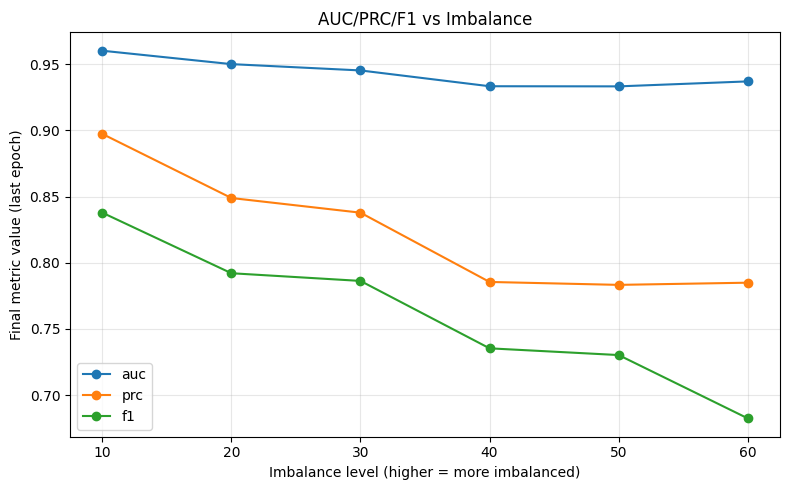

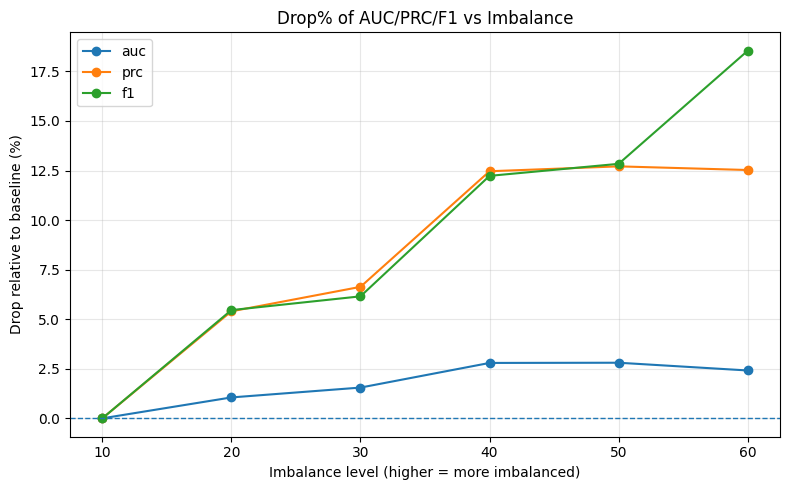

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_last_metrics(all_results, metrics=None):
    """
    all_results: list of dict, each dict like:
        {
          'train_loss': [...], 'val_loss': [...], 'auc': [...], 'prc': [...], 'f1': [...]
        }
    metrics: list of metric names you want to track. If None, auto-detect common ones.
    return:
        last_vals: dict(metric -> np.array shape [n_runs])
    """
    if metrics is None:
        # 自动从第一组里找指标 key
        metrics = list(all_results[0].keys())

    n = len(all_results)
    last_vals = {m: np.zeros(n, dtype=float) for m in metrics}

    for i, res in enumerate(all_results):
        for m in metrics:
            if m not in res:
                raise KeyError(f"Metric '{m}' not found in run {i}.")
            if len(res[m]) == 0:
                raise ValueError(f"Metric '{m}' list is empty in run {i}.")
            last_vals[m][i] = float(res[m][-1])  # 取最后一个

    return last_vals

def percent_drop(last_vals, baseline_idx=0):
    """
    last_vals: dict(metric -> np.array)
    baseline_idx: which run to treat as baseline (most balanced)
    return:
        drops: dict(metric -> np.array)  # drop% relative to baseline
    """
    drops = {}
    for m, arr in last_vals.items():
        base = arr[baseline_idx]
        # 防止 base=0
        if np.isclose(base, 0):
            drops[m] = np.full_like(arr, np.nan)
        else:
            drops[m] = (base - arr) / base * 100.0
    return drops

def plot_metrics_vs_imbalance(imbalance_levels, last_vals, metrics_to_plot=None, 
                             title="Metrics vs Imbalance"):
    """
    imbalance_levels: list/np.array length n_runs, x-axis
    last_vals: dict(metric -> np.array)
    metrics_to_plot: choose subset to plot; None means plot all
    """
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(last_vals.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = last_vals[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Final metric value (last epoch)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drop_vs_imbalance(imbalance_levels, drops, metrics_to_plot=None,
                           title="Percent drop vs Imbalance"):
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(drops.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = drops[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Drop relative to baseline (%)")
    plt.title(title)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def print_summary_table(imbalance_levels, last_vals, drops, metrics=None):
    if metrics is None:
        metrics = list(last_vals.keys())

    print("=== Final metrics (last epoch) and drop% vs baseline ===")
    header = ["imbalance"] + [f"{m}_final" for m in metrics] + [f"{m}_drop%" for m in metrics]
    print("\t".join(header))

    for i, lvl in enumerate(imbalance_levels):
        row = [str(lvl)]
        row += [f"{last_vals[m][i]:.6f}" for m in metrics]
        row += [("nan" if np.isnan(drops[m][i]) else f"{drops[m][i]:.2f}") for m in metrics]
        print("\t".join(row))


# ==========================
# 你需要改的只有这里
# ==========================

# imbalance_levels: 每组结果对应的不平衡程度（你自己定义）
# 例子：正负样本比 1:1, 1:5, 1:10, 1:20 ...
imbalance_levels = [10, 20, 30, 40,50,60]  # <-- 改成你的

# all_results: 多组训练结果，每组一个 dict
# 下面只放了一个示例，你要把你的多组 dict 都塞进 list
all_results = [
    dict_imb10,
dict_imb20,
dict_imb30,
dict_imb40,
dict_imb50,
dict_imb60
]

# 你想画哪些指标（默认是 all_results[0] 里出现的全部 key）
metrics = ['auc', 'prc', 'f1']  # <-- 想加 val_loss/train_loss 也可以放进来

# ==========================
# 跑起来
# ==========================

last_vals = summarize_last_metrics(all_results, metrics=metrics)
drops = percent_drop(last_vals, baseline_idx=0)

print_summary_table(imbalance_levels, last_vals, drops, metrics=metrics)

plot_metrics_vs_imbalance(
    imbalance_levels, last_vals, metrics_to_plot=metrics,
    title="AUC/PRC/F1 vs Imbalance"
)

plot_drop_vs_imbalance(
    imbalance_levels, drops, metrics_to_plot=metrics,
    title="Drop% of AUC/PRC/F1 vs Imbalance"
)
